Calculations of the expected losses and profitability scenarios for the Chain Forward product based on the given business metrics and projections.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)

np.random.seed(42)

In [ ]:
# Chain Forward product parameters and financial risk assumptions
expected_active_borrowers = 20000  # per month
avg_monthly_interest_per_borrower = 8  # USD
expected_monthly_default_rate = 0.06  # 6%
investment = 4500000  # USD
expected_payback_period = 3

current_customers = 150000
current_avg_monthly_revenue = 12
current_default_rate = 0.035
monthly_new_customers = 8000
monthly_churn_rate = 0.04

avg_loan_amount = 500       # USD
recovery_rate = 0.40        # 40%
LGD = 1 - recovery_rate     # 60%

# Monthly operating cost per active borrower
op_cost_per_borrower = 1.50 # USD

# Monthly funding cost as a percentage of loan exposure
funding_cost_rate = 0.01    # 1%

# Monthly loan exposure
monthly_loan_exposure = expected_active_borrowers * avg_loan_amount

# Expected monthly credit loss
expected_credit_loss = (
    monthly_loan_exposure
    * expected_monthly_default_rate
    * LGD
)

# Monthly operating costs
monthly_operating_costs = (
    expected_active_borrowers * op_cost_per_borrower
)

# Monthly funding costs
monthly_funding_costs = (
    monthly_loan_exposure * funding_cost_rate
)

# Monthly interest income
monthly_interest_income = (
    expected_active_borrowers
    * avg_monthly_interest_per_borrower
)

# Monthly profit
monthly_profit = (
    monthly_interest_income
    - expected_credit_loss
    - monthly_operating_costs
    - monthly_funding_costs
)

print("\nFinancial Risk Analysis")
print("-" * 40)
print("Average loan amount:", avg_loan_amount)
print("Recovery rate:", recovery_rate)
print("LGD:", LGD)
print("Monthly loan exposure:", monthly_loan_exposure)
print("Expected monthly credit loss:", expected_credit_loss)
print("Monthly operating costs:", monthly_operating_costs)
print("Monthly funding costs:", monthly_funding_costs)
print("Monthly interest income:", monthly_interest_income)
print("Monthly profit:", monthly_profit)


Financial Risk Analysis
----------------------------------------
Average loan amount: 500
Recovery rate: 0.4
LGD: 0.6
Monthly loan exposure: 10000000
Expected monthly credit loss: 360000.0
Monthly operating costs: 30000.0
Monthly funding costs: 100000.0
Monthly interest income: 160000
Monthly profit: -330000.0


In [ ]:
# SYNTHETIC CUSTOMER DATA

# SYNTHETIC CUSTOMER DATA

no_customers = 10000

df = pd.DataFrame({
    "customer_id": range(1, no_customers + 1),

    "age": np.random.randint(25, 56, no_customers),

    "roles": np.random.choice(
        ["Buyer", "Supplier", "Distributor", "Retailer"],
        no_customers
    ),

    "country": np.random.choice(
        ["Kenya", "Uganda", "Nigeria", "Ghana"],
        no_customers
    ),

    "business_age_years": np.random.exponential(
        scale=5,
        size=no_customers
    ).clip(0.5, 30),

    "business_sector": np.random.choice(
        ["Agriculture", "Retail", "Manufacturing", "Services"],
        no_customers
    ),

    "loan_amount_usd": np.random.lognormal(
        mean=np.log(500),
        sigma=0.7,
        size=no_customers
    ),

    "loan_duration_days": np.random.randint(
        7, 91, no_customers
    ),

    "monthly_revenue_usd": np.random.lognormal(
        mean=np.log(1500),
        sigma=0.8,
        size=no_customers
    ),

    "transaction_volatility": np.random.uniform(
        0, 1, no_customers
    ),

    "repayment_history": np.random.uniform(
        0.5, 1, no_customers
    ),

    "days_overdue": np.random.exponential(
        scale=10,
        size=no_customers
    ).clip(0, 90),

    "monthly_cash_flow_growth": np.random.normal(
        loc=0.05,
        scale=0.10,
        size=no_customers
    ).clip(-0.5, 0.5),

    "mobile_money_volume": np.random.lognormal(
        mean=np.log(1000),
        sigma=0.8,
        size=no_customers
    ),

    "loan_frequency": np.random.randint(
        1, 12, no_customers
    ),

    "previous_loans": np.random.randint(
        0, 10, no_customers
    ),

    "previous_defaults": np.random.poisson(
        lam=0.3,
        size=no_customers
    ).clip(0, 5),

    "supplier_default_flag": np.random.binomial(
        1, 0.08, no_customers
    ),

    "buyer_concentration": np.random.uniform(
        0.1, 1, no_customers
    )
})

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 19)


,customer_id,age,roles,country,business_age_years,business_sector,loan_amount_usd,loan_duration_days,monthly_revenue_usd,transaction_volatility,repayment_history,days_overdue,monthly_cash_flow_growth,mobile_money_volume,loan_frequency,previous_loans,previous_defaults,supplier_default_flag,buyer_concentration
0,1,48,Retailer,Ghana,9.880086,Retail,971.167981,36,1334.554808,0.575005,0.727654,5.597642,0.063794,923.737971,5,0,0,0,0.631925
1,2,38,Distributor,Ghana,27.261320,Manufacturing,257.386371,75,2785.189347,0.901279,0.718254,1.034129,0.029483,740.574628,8,6,0,0,0.891147
2,3,40,Buyer,Nigeria,0.500000,Agriculture,893.034791,31,1083.201964,0.428418,0.623026,26.521269,-0.010313,1889.621905,4,2,0,0,0.412472
3,4,41,Supplier,Nigeria,0.917049,Manufacturing,354.667848,44,1383.964089,0.850999,0.538115,12.623272,0.123306,263.833554,6,8,0,0,0.390000
4,5,38,Supplier,Kenya,9.379639,Manufacturing,268.372520,89,1292.864959,0.223409,0.529971,24.785189,0.206658,911.215777,11,0,1,0,0.566992


In [ ]:
# DATA QUALITY CHECKs

print("Dataset Information")
print("-" * 40)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique customer IDs:", df["customer_id"].nunique())

Dataset Information
----------------------------------------
Number of rows: 10000
Number of columns: 19

Data types:
customer_id                   int64
age                           int64
roles                        object
country                      object
business_age_years          float64
business_sector              object
loan_amount_usd             float64
loan_duration_days            int64
monthly_revenue_usd         float64
transaction_volatility      float64
repayment_history           float64
days_overdue                float64
monthly_cash_flow_growth    float64
mobile_money_volume         float64
loan_frequency                int64
previous_loans                int64
previous_defaults             int64
supplier_default_flag         int64
buyer_concentration         float64
dtype: object

Missing values:
customer_id                 0
age                         0
roles                       0
country                     0
business_age_years          0
business_sector  

In [ ]:
# DESCRIPTIVE STATISTICS

print("Numerical Variable Summary")
print("-" * 40)

df.describe().T

Numerical Variable Summary
----------------------------------------


,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,5000.500000,2886.895680,1.000000,2500.750000,5000.500000,7500.250000,10000.000000
age,10000.0,40.098300,8.920807,25.000000,32.000000,40.000000,48.000000,55.000000
business_age_years,10000.0,5.042025,4.896529,0.500000,1.444834,3.535168,6.989830,30.000000
loan_amount_usd,10000.0,633.969656,498.395323,38.011176,308.925111,497.074908,794.123864,6816.371966
loan_duration_days,10000.0,48.809100,24.256296,7.000000,28.000000,49.000000,70.000000,90.000000
monthly_revenue_usd,10000.0,2080.935532,1978.470612,63.740536,874.322216,1509.772183,2548.449073,29924.843754
transaction_volatility,10000.0,0.501133,0.289359,0.000023,0.249725,0.502131,0.751474,0.999867
repayment_history,10000.0,0.750798,0.144727,0.500010,0.623867,0.751039,0.877096,0.999804
days_overdue,10000.0,10.107490,10.079110,0.000561,2.944270,7.037850,13.934114,90.000000
monthly_cash_flow_growth,10000.0,0.048197,0.099200,-0.336599,-0.019441,0.048242,0.115786,0.406756


In [ ]:
# CATEGORICAL VARIABLE DISTRIBUTIONS

categorical_columns = [
    "roles",
    "country",
    "business_sector"
]

for column in categorical_columns:
    print(f"\n{column.upper()}")
    print("-" * 40)
    print(df[column].value_counts())
    print("\nPercentage:")
    print((df[column].value_counts(normalize=True) * 100).round(2))


ROLES
----------------------------------------
roles
Retailer       2514
Distributor    2511
Supplier       2507
Buyer          2468
Name: count, dtype: int64

Percentage:
roles
Retailer       25.14
Distributor    25.11
Supplier       25.07
Buyer          24.68
Name: proportion, dtype: float64

COUNTRY
----------------------------------------
country
Kenya      2558
Ghana      2513
Uganda     2465
Nigeria    2464
Name: count, dtype: int64

Percentage:
country
Kenya      25.58
Ghana      25.13
Uganda     24.65
Nigeria    24.64
Name: proportion, dtype: float64

BUSINESS_SECTOR
----------------------------------------
business_sector
Services         2558
Manufacturing    2530
Retail           2488
Agriculture      2424
Name: count, dtype: int64

Percentage:
business_sector
Services         25.58
Manufacturing    25.30
Retail           24.88
Agriculture      24.24
Name: proportion, dtype: float64


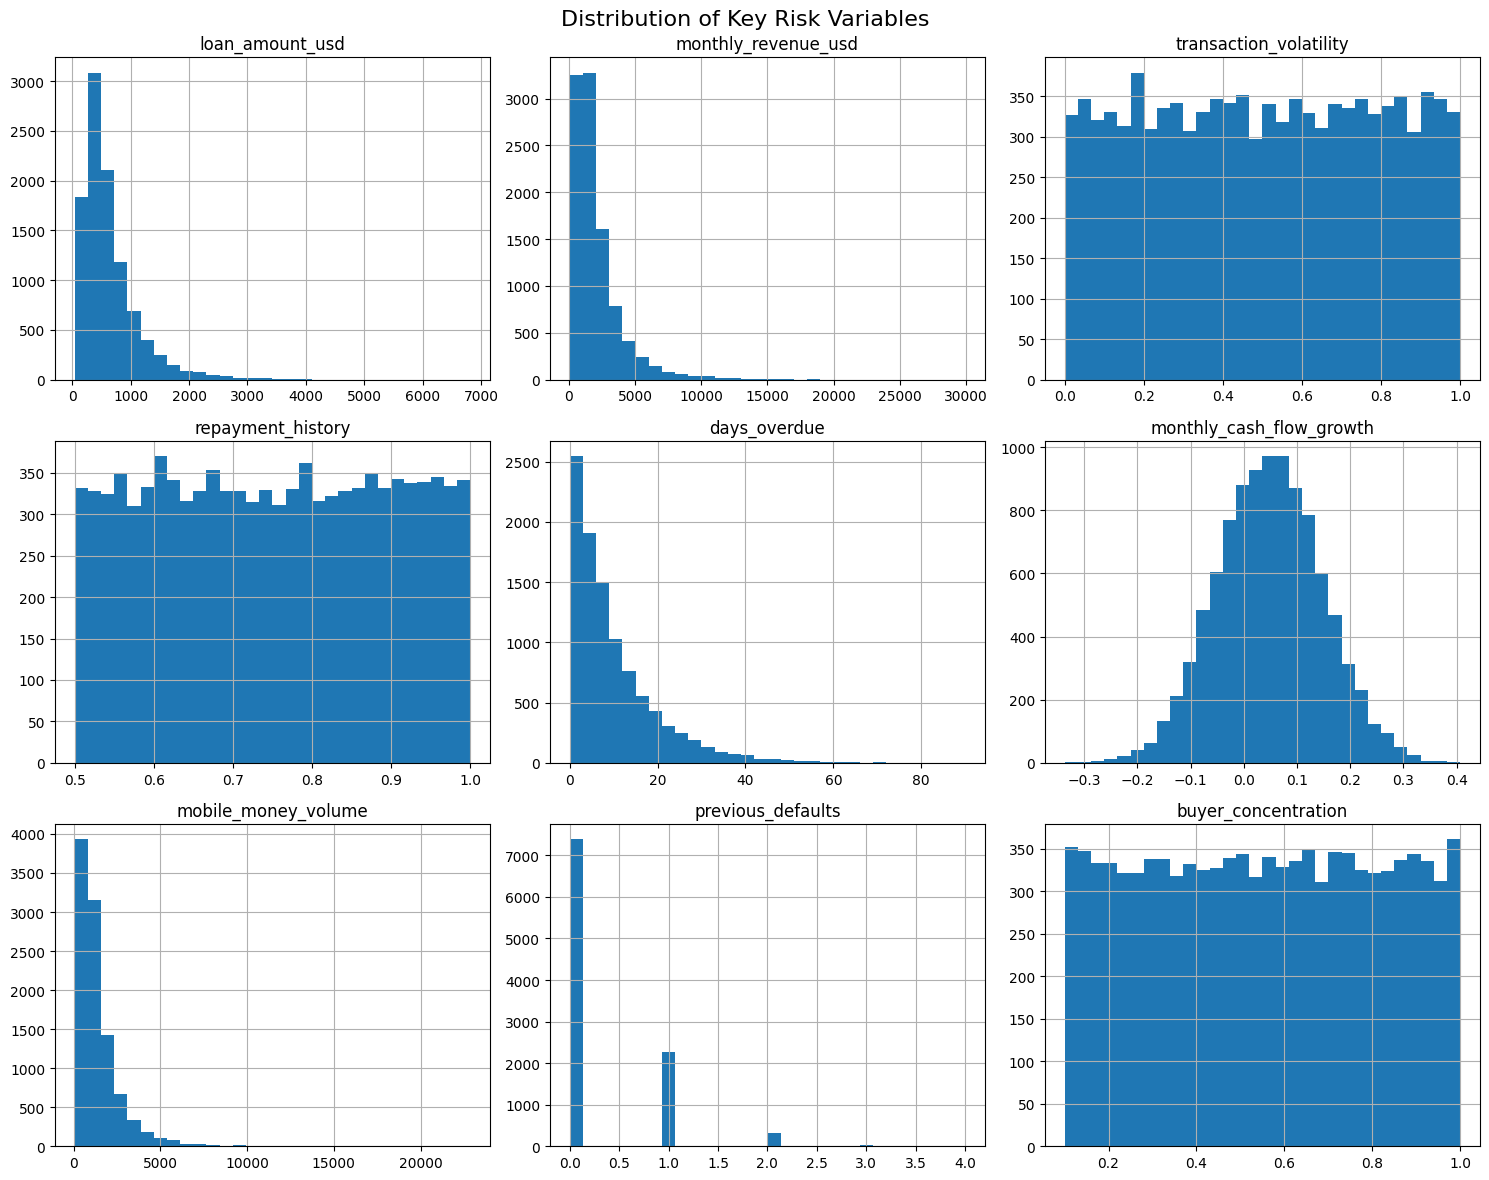

In [ ]:
# DISTRIBUTION OF KEY RISK VARIABLES

risk_variables = [
    "loan_amount_usd",
    "monthly_revenue_usd",
    "transaction_volatility",
    "repayment_history",
    "days_overdue",
    "monthly_cash_flow_growth",
    "mobile_money_volume",
    "previous_defaults",
    "buyer_concentration"
]

df[risk_variables].hist(
    figsize=(15, 12),
    bins=30
)

plt.suptitle("Distribution of Key Risk Variables", fontsize=16)
plt.tight_layout()
plt.show()

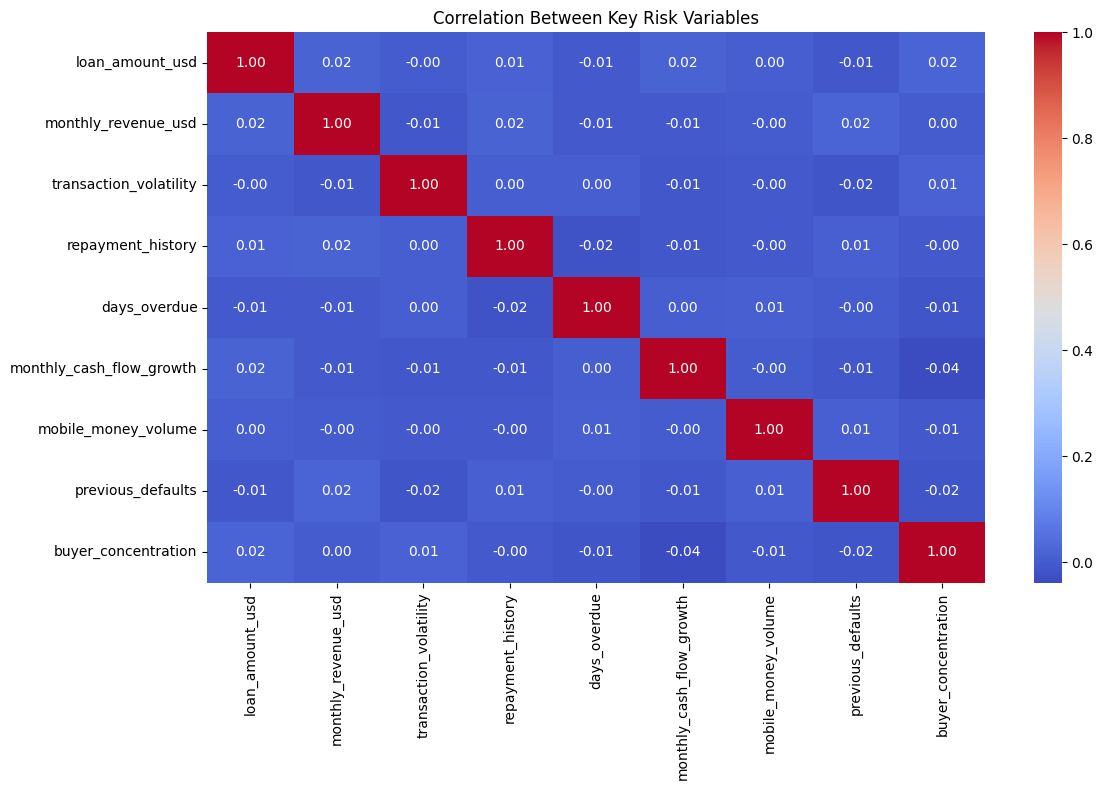

In [ ]:
# CORRELATION ANALYSIS

correlation_matrix = df[risk_variables].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Key Risk Variables")
plt.tight_layout()
plt.show()

In [ ]:
# RISK INDICATORS BY BUSINESS SECTOR

sector_risk = df.groupby("business_sector")[[
    "loan_amount_usd",
    "monthly_revenue_usd",
    "transaction_volatility",
    "repayment_history",
    "days_overdue",
    "monthly_cash_flow_growth",
    "previous_defaults",
    "buyer_concentration"
]].mean().round(2)

sector_risk

,loan_amount_usd,monthly_revenue_usd,transaction_volatility,repayment_history,days_overdue,monthly_cash_flow_growth,previous_defaults,buyer_concentration
business_sector,,,,,,,,
Agriculture,640.40,2069.44,0.50,0.74,10.03,0.05,0.31,0.56
Manufacturing,640.33,2142.79,0.51,0.75,10.09,0.05,0.30,0.54
Retail,632.93,2021.75,0.49,0.75,10.38,0.05,0.30,0.55
Services,622.60,2088.21,0.50,0.76,9.93,0.05,0.29,0.55


In [ ]:
# RISK INDICATORS BY COUNTRY

country_risk = df.groupby("country")[[
    "loan_amount_usd",
    "monthly_revenue_usd",
    "transaction_volatility",
    "repayment_history",
    "days_overdue",
    "monthly_cash_flow_growth",
    "previous_defaults",
    "buyer_concentration"
]].mean().round(2)

country_risk

,loan_amount_usd,monthly_revenue_usd,transaction_volatility,repayment_history,days_overdue,monthly_cash_flow_growth,previous_defaults,buyer_concentration
country,,,,,,,,
Ghana,624.28,2094.43,0.50,0.75,10.10,0.05,0.30,0.54
Kenya,648.42,2095.77,0.49,0.75,10.22,0.05,0.30,0.56
Nigeria,643.17,2101.42,0.50,0.75,10.03,0.05,0.30,0.55
Uganda,619.65,2031.31,0.50,0.75,10.09,0.05,0.31,0.55


In [ ]:
# RISK INDICATORS BY VALUE-CHAIN ROLE

role_risk = df.groupby("roles")[[
    "loan_amount_usd",
    "monthly_revenue_usd",
    "transaction_volatility",
    "repayment_history",
    "days_overdue",
    "monthly_cash_flow_growth",
    "previous_defaults",
    "buyer_concentration"
]].mean().round(2)

role_risk

,loan_amount_usd,monthly_revenue_usd,transaction_volatility,repayment_history,days_overdue,monthly_cash_flow_growth,previous_defaults,buyer_concentration
roles,,,,,,,,
Buyer,636.75,2045.69,0.49,0.75,10.00,0.05,0.32,0.55
Distributor,637.51,2108.09,0.51,0.75,10.24,0.05,0.29,0.55
Retailer,637.44,2152.81,0.51,0.75,10.15,0.05,0.31,0.55
Supplier,624.20,2016.35,0.50,0.75,10.03,0.05,0.29,0.55


In [ ]:
# CREATE DEFAULT OUTCOME

# Loan amount relative to monthly revenue
df["loan_to_revenue"] = (
    df["loan_amount_usd"] / df["monthly_revenue_usd"]
)

# Standardize selected risk factors so they contribute
# on comparable scales to the risk score.
risk_score = (
    0.08 * df["days_overdue"]
    - 3.0 * df["repayment_history"]
    + 1.5 * df["transaction_volatility"]
    - 2.0 * df["monthly_cash_flow_growth"]
    + 0.8 * df["previous_defaults"]
    + 1.0 * df["supplier_default_flag"]
    + 1.0 * df["buyer_concentration"]
    + 2.0 * df["loan_to_revenue"]
)

# Convert the risk score into probabilities.
default_probability = 1 / (1 + np.exp(-risk_score))

# Use the 6% case-study default rate as the target
# for calibrating the synthetic probabilities.
target_default_rate = 0.06

# Adjust the intercept until the average probability
# is close to the target default rate.
intercept = 0

for _ in range(100):
    probabilities = 1 / (
        1 + np.exp(-(risk_score + intercept))
    )

    intercept += np.log(
        target_default_rate / probabilities.mean()
    )

default_probability = 1 / (
    1 + np.exp(-(risk_score + intercept))
)

# Generate the binary default outcome.
df["default"] = np.random.binomial(
    1,
    default_probability
)

print(
    "Simulated default rate:",
    round(df["default"].mean() * 100, 2),
    "%"
)

print("\nDefault counts:")
print(df["default"].value_counts())

Simulated default rate: 5.85 %

Default counts:
default
0    9415
1     585
Name: count, dtype: int64


In [ ]:
# DEFAULT RATE BY BUSINESS SECTOR

sector_default_rate = (
    df.groupby("business_sector")["default"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print("Default Rate by Business Sector (%)")
print("-" * 40)

sector_default_rate

Default Rate by Business Sector (%)
----------------------------------------


,default
business_sector,
Retail,6.83
Agriculture,6.02
Manufacturing,5.93
Services,4.65


In [ ]:
# DEFAULT RATE BY COUNTRY

country_default_rate = (
    df.groupby("country")["default"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print("Default Rate by Country (%)")
print("-" * 40)

country_default_rate

Default Rate by Country (%)
----------------------------------------


,default
country,
Kenya,6.33
Ghana,6.25
Nigeria,5.60
Uganda,5.19


In [ ]:
# DEFAULT RATE BY VALUE-CHAIN ROLE

role_default_rate = (
    df.groupby("roles")["default"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print("Default Rate by Value-Chain Role (%)")
print("-" * 40)

role_default_rate

Default Rate by Value-Chain Role (%)
----------------------------------------


,default
roles,
Buyer,6.12
Retailer,6.05
Distributor,5.77
Supplier,5.46


In [ ]:
# CORRELATION WITH DEFAULT

numeric_columns = df.select_dtypes(include=np.number).columns

default_correlation = (
    df[numeric_columns]
    .corr()["default"]
    .drop("default")
    .sort_values(ascending=False)
)

print("Correlation with Default")
print("-" * 40)

default_correlation.round(4)

Correlation with Default
----------------------------------------


,default
loan_to_revenue,0.5209
loan_amount_usd,0.2638
days_overdue,0.1788
previous_defaults,0.0710
transaction_volatility,0.0503
buyer_concentration,0.0330
supplier_default_flag,0.0287
age,0.0090
loan_frequency,0.0086
mobile_money_volume,0.0048


In [ ]:
# DATA FOR DEFAULT PREDICTION

# Target variable
y = df["default"]

# target and customer ID removed from the predictors
X = df.drop(columns=["default", "customer_id"])

print("Features:", X.shape[1])
print("Target:", y.name)
print("Default rate:", round(y.mean() * 100, 2), "%")

Features: 19
Target: default
Default rate: 5.85 %


In [ ]:
# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nDefault rate in training set:",
      round(y_train.mean() * 100, 2), "%")

print("Default rate in test set:",
      round(y_test.mean() * 100, 2), "%")

Training set: (8000, 19)
Test set: (2000, 19)

Default rate in training set: 5.85 %
Default rate in test set: 5.85 %


In [ ]:
# NUMERICAL AND CATEGORICAL FEATURES

categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

numerical_features = X_train.select_dtypes(
    exclude="object"
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['roles', 'country', 'business_sector']

Numerical features:
['age', 'business_age_years', 'loan_amount_usd', 'loan_duration_days', 'monthly_revenue_usd', 'transaction_volatility', 'repayment_history', 'days_overdue', 'monthly_cash_flow_growth', 'mobile_money_volume', 'loan_frequency', 'previous_loans', 'previous_defaults', 'supplier_default_flag', 'buyer_concentration', 'loan_to_revenue']


In [ ]:
# PREPROCESSING PIPELINE

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
# LOGISTIC REGRESSION MODEL

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# LOGISTIC REGRESSION EVALUATION

y_pred = logistic_model.predict(X_test)
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Performance")
print("-" * 40)

print(classification_report(y_test, y_pred))

print("ROC-AUC:",
      round(roc_auc_score(y_test, y_pred_proba), 4))

print("Average Precision:",
      round(average_precision_score(y_test, y_pred_proba), 4))

Logistic Regression Performance
----------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      1883
           1       0.29      0.84      0.43       117

    accuracy                           0.87      2000
   macro avg       0.64      0.85      0.68      2000
weighted avg       0.95      0.87      0.90      2000

ROC-AUC: 0.9128
Average Precision: 0.6625


In [ ]:
# RANDOM FOREST MODEL

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
# RANDOM FOREST EVALUATION

rf_pred = random_forest_model.predict(X_test)
rf_pred_proba = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest Performance")
print("-" * 40)

print(classification_report(y_test, rf_pred))

print("ROC-AUC:",
      round(roc_auc_score(y_test, rf_pred_proba), 4))

print("Average Precision:",
      round(average_precision_score(y_test, rf_pred_proba), 4))

Random Forest Performance
----------------------------------------
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1883
           1       0.89      0.26      0.41       117

    accuracy                           0.95      2000
   macro avg       0.92      0.63      0.69      2000
weighted avg       0.95      0.95      0.94      2000

ROC-AUC: 0.8975
Average Precision: 0.616


In [ ]:
# THRESHOLD TUNING

thresholds = np.arange(0.10, 0.91, 0.01)

f1_scores = []

for threshold in thresholds:
    predictions = (
        y_pred_proba >= threshold
    ).astype(int)

    f1_scores.append(
        f1_score(y_test, predictions)
    )

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print("Best threshold:", round(best_threshold, 2))
print("Best F1-score:", round(best_f1, 4))

Best threshold: 0.87
Best F1-score: 0.6306


In [ ]:
# OPTIMIZED THRESHOLD EVALUATION

optimized_pred = (
    y_pred_proba >= best_threshold
).astype(int)

print("Logistic Regression at Optimized Threshold")
print("-" * 50)

print(classification_report(
    y_test,
    optimized_pred
))

print("Precision:",
      round(precision_score(y_test, optimized_pred), 4))

print("Recall:",
      round(recall_score(y_test, optimized_pred), 4))

print("F1-score:",
      round(f1_score(y_test, optimized_pred), 4))

Logistic Regression at Optimized Threshold
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1883
           1       0.67      0.60      0.63       117

    accuracy                           0.96      2000
   macro avg       0.82      0.79      0.80      2000
weighted avg       0.96      0.96      0.96      2000

Precision: 0.6667
Recall: 0.5983
F1-score: 0.6306


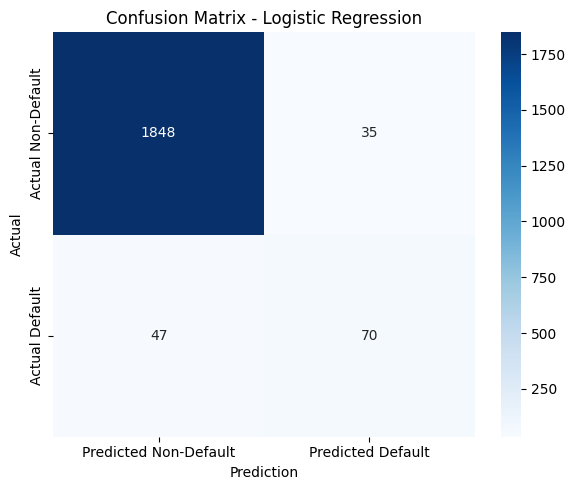

In [ ]:
# CONFUSION MATRIX AT OPTIMIZED THRESHOLD

cm = confusion_matrix(
    y_test,
    optimized_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Non-Default", "Predicted Default"],
    yticklabels=["Actual Non-Default", "Actual Default"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
# MODEL COMPARISON

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_proba),
        roc_auc_score(y_test, rf_pred_proba)
    ],

    "Average Precision": [
        average_precision_score(y_test, y_pred_proba),
        average_precision_score(y_test, rf_pred_proba)
    ],

    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1-score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison.round(4)

,Model,ROC-AUC,Average Precision,Precision,Recall,F1-score
0,Logistic Regression,0.9128,0.6625,0.2874,0.8376,0.4279
1,Random Forest,0.8975,0.6160,0.8857,0.2650,0.4079


In [ ]:
# CUSTOMER SEGMENTATION

segmentation_features = [
    "loan_amount_usd",
    "monthly_revenue_usd",
    "repayment_history",
    "days_overdue",
    "mobile_money_volume",
    "previous_defaults",
    "buyer_concentration",
    "business_age_years"
]

X_segmentation = df[segmentation_features]

# Standardize variables
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_segmentation)

print("Segmentation features:")
print(segmentation_features)

print("\nScaled data shape:", X_scaled.shape)

Segmentation features:
['loan_amount_usd', 'monthly_revenue_usd', 'repayment_history', 'days_overdue', 'mobile_money_volume', 'previous_defaults', 'buyer_concentration', 'business_age_years']

Scaled data shape: (10000, 8)


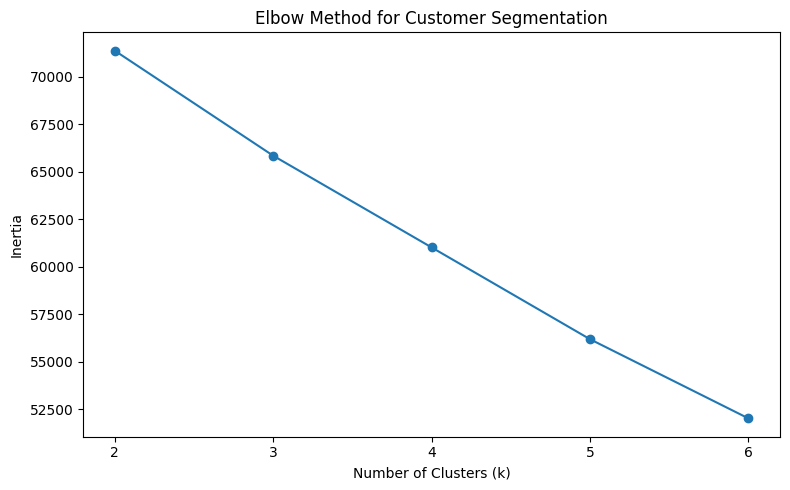

In [ ]:
# ELBOW METHOD FOR K-MEANS

inertia = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 7),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Customer Segmentation")
plt.xticks(range(2, 7))

plt.tight_layout()
plt.show()

In [ ]:
# FINAL K-MEANS CUSTOMER SEGMENTATION

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

print("Customer segments created successfully.")

print("\nCustomers in each segment:")
print(df["cluster"].value_counts().sort_index())

Customer segments created successfully.

Customers in each segment:
cluster
0    6128
1    1471
2    2401
Name: count, dtype: int64


In [ ]:
# CUSTOMER SEGMENT PROFILES

cluster_profile = (
    df.groupby("cluster")[segmentation_features]
      .mean()
      .round(2)
)

cluster_profile

,loan_amount_usd,monthly_revenue_usd,repayment_history,days_overdue,mobile_money_volume,previous_defaults,buyer_concentration,business_age_years
cluster,,,,,,,,
0,639.40,2033.43,0.75,10.04,1357.35,0.00,0.55,3.22
1,620.94,2223.13,0.76,10.33,1549.33,0.15,0.54,14.23
2,628.10,2115.07,0.75,10.13,1396.76,1.16,0.54,4.07


In [ ]:
# DEFAULT RATE BY CUSTOMER SEGMENT

cluster_default_rate = (
    df.groupby("cluster")["default"]
      .mean()
      .mul(100)
      .round(2)
)

cluster_default_rate

,default
cluster,
0,5.22
1,4.21
2,8.45


In [ ]:
# BUSINESS RISK SEGMENT LABELS

risk_segment_mapping = {
    0: "Medium Risk",
    1: "Low Risk",
    2: "High Risk"
}

df["risk_segment"] = df["cluster"].map(
    risk_segment_mapping
)

print("Risk segments created successfully.")

print("\nCustomer counts by risk segment:")
print(df["risk_segment"].value_counts())

Risk segments created successfully.

Customer counts by risk segment:
risk_segment
Medium Risk    6128
High Risk      2401
Low Risk       1471
Name: count, dtype: int64


In [ ]:
# RISK SEGMENT DISTRIBUTION BY BUSINESS SECTOR

sector_segment = pd.crosstab(
    df["business_sector"],
    df["risk_segment"],
    normalize="index"
).mul(100).round(2)

sector_segment

risk_segment,High Risk,Low Risk,Medium Risk
business_sector,,,
Agriculture,24.38,14.52,61.10
Manufacturing,22.96,15.22,61.82
Retail,24.28,15.23,60.49
Services,24.43,13.88,61.69


In [ ]:
# RISK SEGMENT DISTRIBUTION BY VALUE-CHAIN ROLE

role_segment = pd.crosstab(
    df["roles"],
    df["risk_segment"],
    normalize="index"
).mul(100).round(2)

role_segment

risk_segment,High Risk,Low Risk,Medium Risk
roles,,,
Buyer,24.92,14.79,60.29
Distributor,23.70,14.77,61.53
Retailer,24.07,15.35,60.58
Supplier,23.37,13.92,62.70


In [ ]:
# RISK SEGMENT SUMMARY

segment_summary = (
    df.groupby("risk_segment")
      .agg(
          customers=("customer_id", "count"),
          default_rate=("default", "mean"),
          avg_previous_defaults=("previous_defaults", "mean"),
          avg_days_overdue=("days_overdue", "mean"),
          avg_repayment_history=("repayment_history", "mean"),
          avg_business_age=("business_age_years", "mean")
      )
      .round(2)
)

segment_summary["default_rate"] = (
    segment_summary["default_rate"] * 100
).round(2)

segment_summary

,customers,default_rate,avg_previous_defaults,avg_days_overdue,avg_repayment_history,avg_business_age
risk_segment,,,,,,
High Risk,2401,8.0,1.16,10.13,0.75,4.07
Low Risk,1471,4.0,0.15,10.33,0.76,14.23
Medium Risk,6128,5.0,0.00,10.04,0.75,3.22


In [ ]:
# SCENARIO ANALYSIS

scenarios = {
    "Optimistic": 0.04,
    "Base Case": 0.06,
    "Pessimistic": 0.08
}

scenario_results = []

for scenario, default_rate in scenarios.items():

    expected_credit_loss = (
        monthly_loan_exposure
        * default_rate
        * LGD
    )

    monthly_profit = (
        monthly_interest_income
        - expected_credit_loss
        - monthly_operating_costs
        - monthly_funding_costs
    )

    scenario_results.append({
        "Scenario": scenario,
        "Default Rate": default_rate,
        "Expected Credit Loss": expected_credit_loss,
        "Monthly Profit": monthly_profit
    })

scenario_results = pd.DataFrame(scenario_results)

scenario_results

,Scenario,Default Rate,Expected Credit Loss,Monthly Profit
0,Optimistic,0.04,240000.0,-210000.0
1,Base Case,0.06,360000.0,-330000.0
2,Pessimistic,0.08,480000.0,-450000.0


In [ ]:
# 3-YEAR SCENARIO PROFITABILITY

total_months = expected_payback_period * 12

scenario_results["3-Year Operating Profit"] = (
    scenario_results["Monthly Profit"] * total_months
)

scenario_results["Net Outcome After Investment"] = (
    scenario_results["3-Year Operating Profit"] - investment
)

scenario_results["ROI on Investment (%)"] = (
    scenario_results["3-Year Operating Profit"]
    / investment
) * 100

scenario_results.round(2)

,Scenario,Default Rate,Expected Credit Loss,Monthly Profit,3-Year Operating Profit,Net Outcome After Investment,ROI on Investment (%)
0,Optimistic,0.04,240000.0,-210000.0,-7560000.0,-12060000.0,-168.0
1,Base Case,0.06,360000.0,-330000.0,-11880000.0,-16380000.0,-264.0
2,Pessimistic,0.08,480000.0,-450000.0,-16200000.0,-20700000.0,-360.0


In [ ]:
# BREAK-EVEN DEFAULT RATE

break_even_default_rate = (
    monthly_interest_income
    - monthly_operating_costs
    - monthly_funding_costs
) / (monthly_loan_exposure * LGD)

print(
    "Break-even default rate:",
    round(break_even_default_rate * 100, 2),
    "%"
)

Break-even default rate: 0.5 %


In [ ]:
# VALIDATE BREAK-EVEN POINT

break_even_credit_loss = (
    monthly_loan_exposure
    * break_even_default_rate
    * LGD
)

break_even_profit = (
    monthly_interest_income
    - break_even_credit_loss
    - monthly_operating_costs
    - monthly_funding_costs
)

print("Break-even default rate:",
      round(break_even_default_rate * 100, 2), "%")

print("Expected credit loss at break-even: $",
      round(break_even_credit_loss, 2))

print("Monthly profit at break-even: $",
      round(break_even_profit, 2))

Break-even default rate: 0.5 %
Expected credit loss at break-even: $ 30000.0
Monthly profit at break-even: $ 0.0


In [ ]:
# LOGISTIC REGRESSION FEATURE IMPORTANCE

# the trained classifier
logistic_classifier = logistic_model.named_steps["classifier"]

# feature names after preprocessing
feature_names = logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# table of coefficients
coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logistic_classifier.coef_[0]
})

# Sort by absolute coefficient
coefficient_table["Absolute_Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table = (
    coefficient_table
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
    .drop(columns="Absolute_Coefficient")
)

coefficient_table.head(10)

,Feature,Coefficient
15,num__loan_to_revenue,1.682965
7,num__days_overdue,0.926187
12,num__previous_defaults,0.515632
5,num__transaction_volatility,0.502990
6,num__repayment_history,-0.366765
8,num__monthly_cash_flow_growth,-0.333830
13,num__supplier_default_flag,0.224145
14,num__buyer_concentration,0.201878
23,cat__business_sector_Retail,0.194228
16,cat__roles_Distributor,-0.186512


In [ ]:
# PRICING BY RISK SEGMENT

# Using the observed default rate in each customer segment
segment_pricing = (
    df.groupby("risk_segment")
    .agg(
        customers=("customer_id", "count"),
        default_rate=("default", "mean")
    )
    .reset_index()
)

# expected credit loss per borrower
segment_pricing["expected_credit_loss"] = (
    avg_loan_amount
    * segment_pricing["default_rate"]
    * LGD
)

#  monthly funding cost per borrower
segment_pricing["funding_cost"] = (
    avg_loan_amount * funding_cost_rate
)

# Operating cost per borrower
segment_pricing["operating_cost"] = op_cost_per_borrower

# Minimum monthly income required to break even
segment_pricing["break_even_income"] = (
    segment_pricing["expected_credit_loss"]
    + segment_pricing["funding_cost"]
    + segment_pricing["operating_cost"]
)

segment_pricing

,risk_segment,customers,default_rate,expected_credit_loss,funding_cost,operating_cost,break_even_income
0,High Risk,2401,0.084548,25.364431,5.0,1.5,31.864431
1,Low Risk,1471,0.042148,12.644460,5.0,1.5,19.144460
2,Medium Risk,6128,0.052219,15.665796,5.0,1.5,22.165796


In [ ]:
# RISK-BASED PRICING

# Illustrative target profit margin
target_margin = 0.20

# minimum income needed to cover costsand achieve the target margin
segment_pricing["recommended_income"] = (
    segment_pricing["break_even_income"] / (1 - target_margin)
)

# Rounded
segment_pricing["recommended_income"] = (
    segment_pricing["recommended_income"].round(2)
)

segment_pricing[
    [
        "risk_segment",
        "default_rate",
        "break_even_income",
        "recommended_income"
    ]
]

,risk_segment,default_rate,break_even_income,recommended_income
0,High Risk,0.084548,31.864431,39.83
1,Low Risk,0.042148,19.144460,23.93
2,Medium Risk,0.052219,22.165796,27.71


In [ ]:
# PRICING DIFFERENCE BY RISK SEGMENT

low_risk_income = segment_pricing.loc[
    segment_pricing["risk_segment"] == "Low Risk",
    "recommended_income"
].iloc[0]

segment_pricing["premium_vs_low_risk"] = (
    (segment_pricing["recommended_income"] / low_risk_income) - 1
) * 100

segment_pricing["premium_vs_low_risk"] = (
    segment_pricing["premium_vs_low_risk"].round(1)
)

segment_pricing[
    [
        "risk_segment",
        "recommended_income",
        "premium_vs_low_risk"
    ]
]

,risk_segment,recommended_income,premium_vs_low_risk
0,High Risk,39.83,66.4
1,Low Risk,23.93,0.0
2,Medium Risk,27.71,15.8


In [ ]:
# EXPORT RISK SEGMENT PRICING RESULTS

segment_pricing.to_csv(
    "risk_segment_pricing.csv",
    index=False
)

segment_pricing

,risk_segment,customers,default_rate,expected_credit_loss,funding_cost,operating_cost,break_even_income,recommended_income,premium_vs_low_risk
0,High Risk,2401,0.084548,25.364431,5.0,1.5,31.864431,39.83,66.4
1,Low Risk,1471,0.042148,12.644460,5.0,1.5,19.144460,23.93,0.0
2,Medium Risk,6128,0.052219,15.665796,5.0,1.5,22.165796,27.71,15.8


In [ ]:
# CUSTOMER-LEVEL RISK OUTPUT

# predicted probability of default from the logistic regression model
df["predicted_default_probability"] = logistic_model.predict_proba(X)[:, 1]

# clean customer-level risk output
customer_risk_output = df[
    [
        "customer_id",
        "risk_segment",
        "predicted_default_probability",
        "loan_amount_usd",
        "monthly_revenue_usd",
        "loan_to_revenue",
        "days_overdue",
        "previous_defaults",
        "transaction_volatility",
        "repayment_history",
        "monthly_cash_flow_growth"
    ]
].copy()

# Export to CSV
customer_risk_output.to_csv(
    "customer_risk_output.csv",
    index=False
)

customer_risk_output.head()

,customer_id,risk_segment,predicted_default_probability,loan_amount_usd,monthly_revenue_usd,loan_to_revenue,days_overdue,previous_defaults,transaction_volatility,repayment_history,monthly_cash_flow_growth
0,1,Low Risk,0.168187,971.167981,1334.554808,0.727709,5.597642,0,0.575005,0.727654,0.063794
1,2,Low Risk,0.032959,257.386371,2785.189347,0.092413,1.034129,0,0.901279,0.718254,0.029483
2,3,Medium Risk,0.644990,893.034791,1083.201964,0.824440,26.521269,0,0.428418,0.623026,-0.010313
3,4,Medium Risk,0.184549,354.667848,1383.964089,0.256270,12.623272,0,0.850999,0.538115,0.123306
4,5,High Risk,0.364782,268.372520,1292.864959,0.207580,24.785189,1,0.223409,0.529971,0.206658


In [ ]:
# FINAL MODEL PERFORMANCE SUMMARY

model_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC_AUC": [
        roc_auc_score(y_test, logistic_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, random_forest_model.predict_proba(X_test)[:, 1])
    ],
    "Average_Precision": [
        average_precision_score(
            y_test,
            logistic_model.predict_proba(X_test)[:, 1]
        ),
        average_precision_score(
            y_test,
            random_forest_model.predict_proba(X_test)[:, 1]
        )
    ]
})

model_summary

,Model,ROC_AUC,Average_Precision
0,Logistic Regression,0.912787,0.662463
1,Random Forest,0.897506,0.616027


In [ ]:
# EXPORT MODEL COMPARISON

model_summary.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [ ]:
# FINAL PROJECT CHECK

print("Dataset shape:", df.shape)
print("Default rate:", round(df["default"].mean() * 100, 2), "%")

print("\nRisk segments:")
print(df["risk_segment"].value_counts())

print("\nModel comparison:")
print(model_summary)

print("\nBreak-even default rate:",
      round(break_even_default_rate * 100, 2), "%")

print("\nScenario results:")
print(
    scenario_results[
        [
            "Scenario",
            "Default Rate",
            "Expected Credit Loss",
            "Monthly Profit",
            "3-Year Operating Profit",
            "ROI on Investment (%)"
        ]
    ]
)

Dataset shape: (10000, 24)
Default rate: 5.85 %

Risk segments:
risk_segment
Medium Risk    6128
High Risk      2401
Low Risk       1471
Name: count, dtype: int64

Model comparison:
                 Model   ROC_AUC  Average_Precision
0  Logistic Regression  0.912787           0.662463
1        Random Forest  0.897506           0.616027

Break-even default rate: 0.5 %

Scenario results:
      Scenario  Default Rate  Expected Credit Loss  Monthly Profit  \
0   Optimistic          0.04              240000.0       -210000.0   
1    Base Case          0.06              360000.0       -330000.0   
2  Pessimistic          0.08              480000.0       -450000.0   

   3-Year Operating Profit  ROI on Investment (%)  
0               -7560000.0                 -168.0  
1              -11880000.0                 -264.0  
2              -16200000.0                 -360.0  


In [ ]:
# SAVING THE FINAL LOGISTIC REGRESSION MODEL

import joblib

joblib.dump(
    logistic_model,
    "logistic_model.pkl"
)

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


In [ ]:
# SAVED MODEL FILE EXISTS
import os

print("Model file exists:", os.path.exists("logistic_model.pkl"))
print("File size:", os.path.getsize("logistic_model.pkl"), "bytes")

Model file exists: True
File size: 5761 bytes
